<a href="https://colab.research.google.com/github/Akulverma2/AIML-projects/blob/main/customerdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix

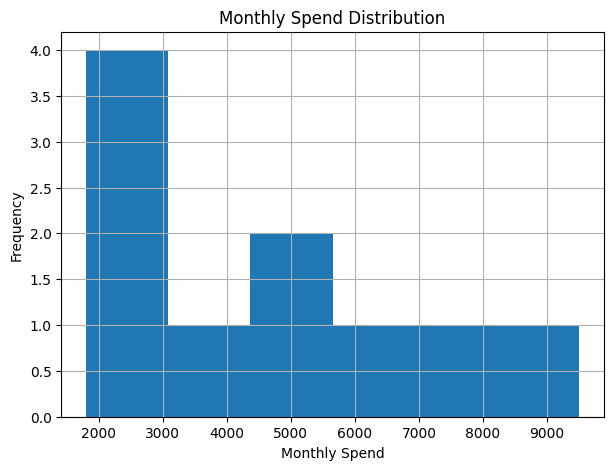

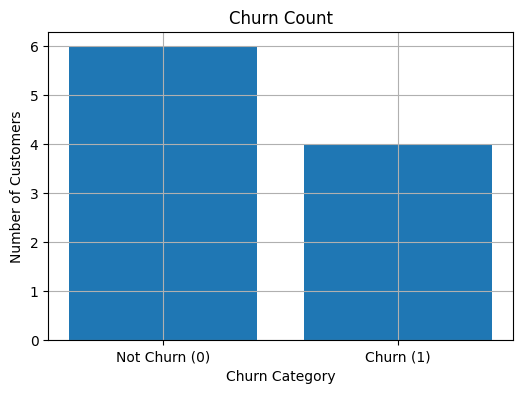

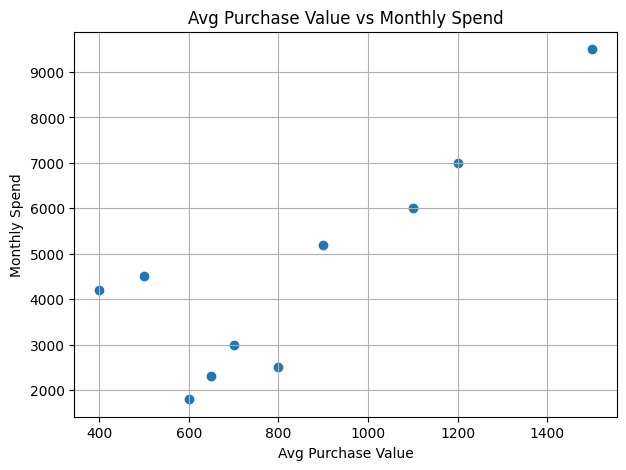

In [ ]:
data = pd.read_csv("customer_data.csv")
# 1) Histogram: Monthly Spend Distribution
plt.figure(figsize=(7,5))
plt.hist(data["MonthlySpend"], bins=6)
plt.title("Monthly Spend Distribution")
plt.xlabel("Monthly Spend")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# 2) Bar Chart: Churn Count
churn_counts = data["Churn"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(["Not Churn (0)", "Churn (1)"], churn_counts)
plt.title("Churn Count")
plt.xlabel("Churn Category")
plt.ylabel("Number of Customers")
plt.grid(True)
plt.show()

# 3) Scatter Plot: AvgPurchaseValue vs MonthlySpend
plt.figure(figsize=(7,5))
plt.scatter(data["AvgPurchaseValue"], data["MonthlySpend"])
plt.title("Avg Purchase Value vs Monthly Spend")
plt.xlabel("Avg Purchase Value")
plt.ylabel("Monthly Spend")
plt.grid(True)
plt.show()

In [ ]:
X = data[['Age', 'TenureMonths', 'VisitsPerMonth', 'AvgPurchaseValue']]
y_spend = data['MonthlySpend']   # Linear Regression Target
y_churn = data['Churn']          # Logistic Regression Target
# Train-Test Split
X_train, X_test, y_spend_train, y_spend_test = train_test_split(
    X, y_spend, test_size=0.2, random_state=42)

X_train2, X_test2, y_churn_train, y_churn_test = train_test_split(
    X, y_churn, test_size=0.2, random_state=42)

------ Linear Regression (Monthly Spend Prediction) ------
MAE: 339.2267449468104
R2 Score: 0.486080726810601


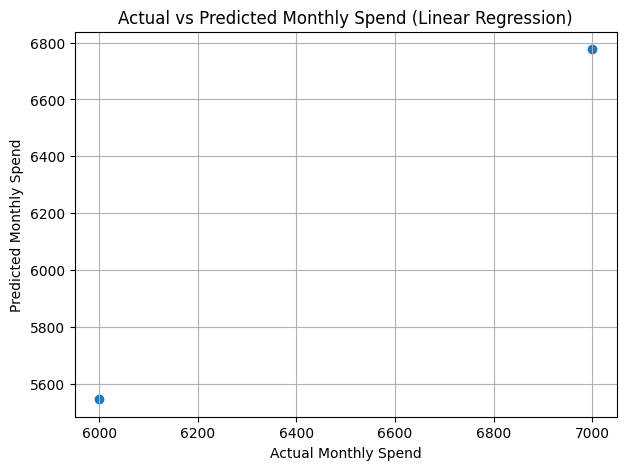

In [ ]:
# Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train, y_spend_train)

spend_pred = linear_model.predict(X_test)

print("------ Linear Regression (Monthly Spend Prediction) ------")
print("MAE:", mean_absolute_error(y_spend_test, spend_pred))
print("R2 Score:", r2_score(y_spend_test, spend_pred))

# 4) Graph: Actual vs Predicted Monthly Spend
plt.figure(figsize=(7,5))
plt.scatter(y_spend_test, spend_pred)
plt.title("Actual vs Predicted Monthly Spend (Linear Regression)")
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")
plt.grid(True)
plt.show()


------ Logistic Regression (Churn Prediction) ------
Accuracy: 1.0
Confusion Matrix:
 [[2 0]
 [0 0]]


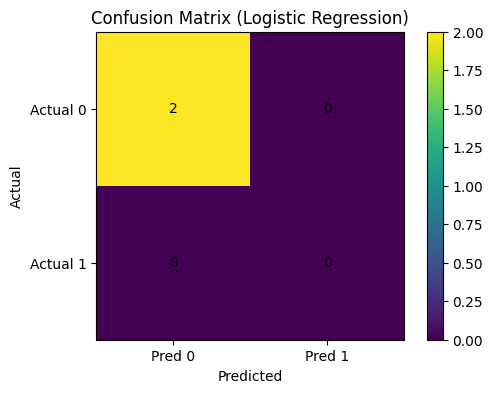

In [ ]:
# Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train2, y_churn_train)

churn_pred = log_model.predict(X_test2)

print("\n------ Logistic Regression (Churn Prediction) ------")
print("Accuracy:", accuracy_score(y_churn_test, churn_pred))
cm = confusion_matrix(y_churn_test, churn_pred, labels=[0, 1])
print("Confusion Matrix:\n", cm)

# 5) Confusion Matrix Plot (Matplotlib)
plt.figure(figsize=(6,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix (Logistic Regression)")
plt.colorbar()

plt.xticks([0, 1], ["Pred 0", "Pred 1"])
plt.yticks([0, 1], ["Actual 0", "Actual 1"])

# Add numbers inside matrix
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# Test on New Customer Data
new_customer = [[22, 6, 8, 500]]  # Age, TenureMonths, VisitsPerMonth, AvgPurchaseValue

pred_spend = linear_model.predict(new_customer)[0]
pred_churn = log_model.predict(new_customer)[0]

print("\n------ New Customer Prediction ------")
print("Predicted Monthly Spend:", round(pred_spend, 2))
print("Churn Prediction:", "Yes" if pred_churn == 1 else "No")


------ New Customer Prediction ------
Predicted Monthly Spend: 4416.53
Churn Prediction: No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
